In [1]:
# a script to go over the ATG profiles and check the conservation of 'ATG' sites
# author: Sheng-Kai Hsu
# date created: 2023.11.16
# data last edited: 2023.11.16
rm(list=ls())

In [2]:
library(limma)
library(parallel)
library(Biostrings)
library(LSD)

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: XVector

Loading required package: GenomeInfoDb


Attaching package: ‘

In [3]:
# load 'ATG' profiles
dat_flist = list.files("/workdir/sh2246/p_phyloGWAS/output/ATGProfile",full.names = T)
dat_list = mclapply(dat_flist,function(x) read.table(x,header = T,sep = "\t"),mc.cores = 30)

In [4]:
names(dat_list) = gsub(".atgProfile.txt","",strsplit2(dat_flist,"/")[,ncol(strsplit2(dat_flist,"/"))])

[1] 45843

firstATGConservation
    0     1     2     3     4     5     6     7     8     9    10    11    12 
11966  2096  1022   749   479   470   342   330   263   296   239   260   235 
   13    14    15    16    17    18    19    20    21    22    23    24    25 
  271   264   257   269   310   298   344   301   395   426   510   684   947 
   26    27    28    29    30    31    32    33    34    35    36    37 
 1285  2006  2325  2580  2708  2424  2162  1886  1430  1322   966   702 

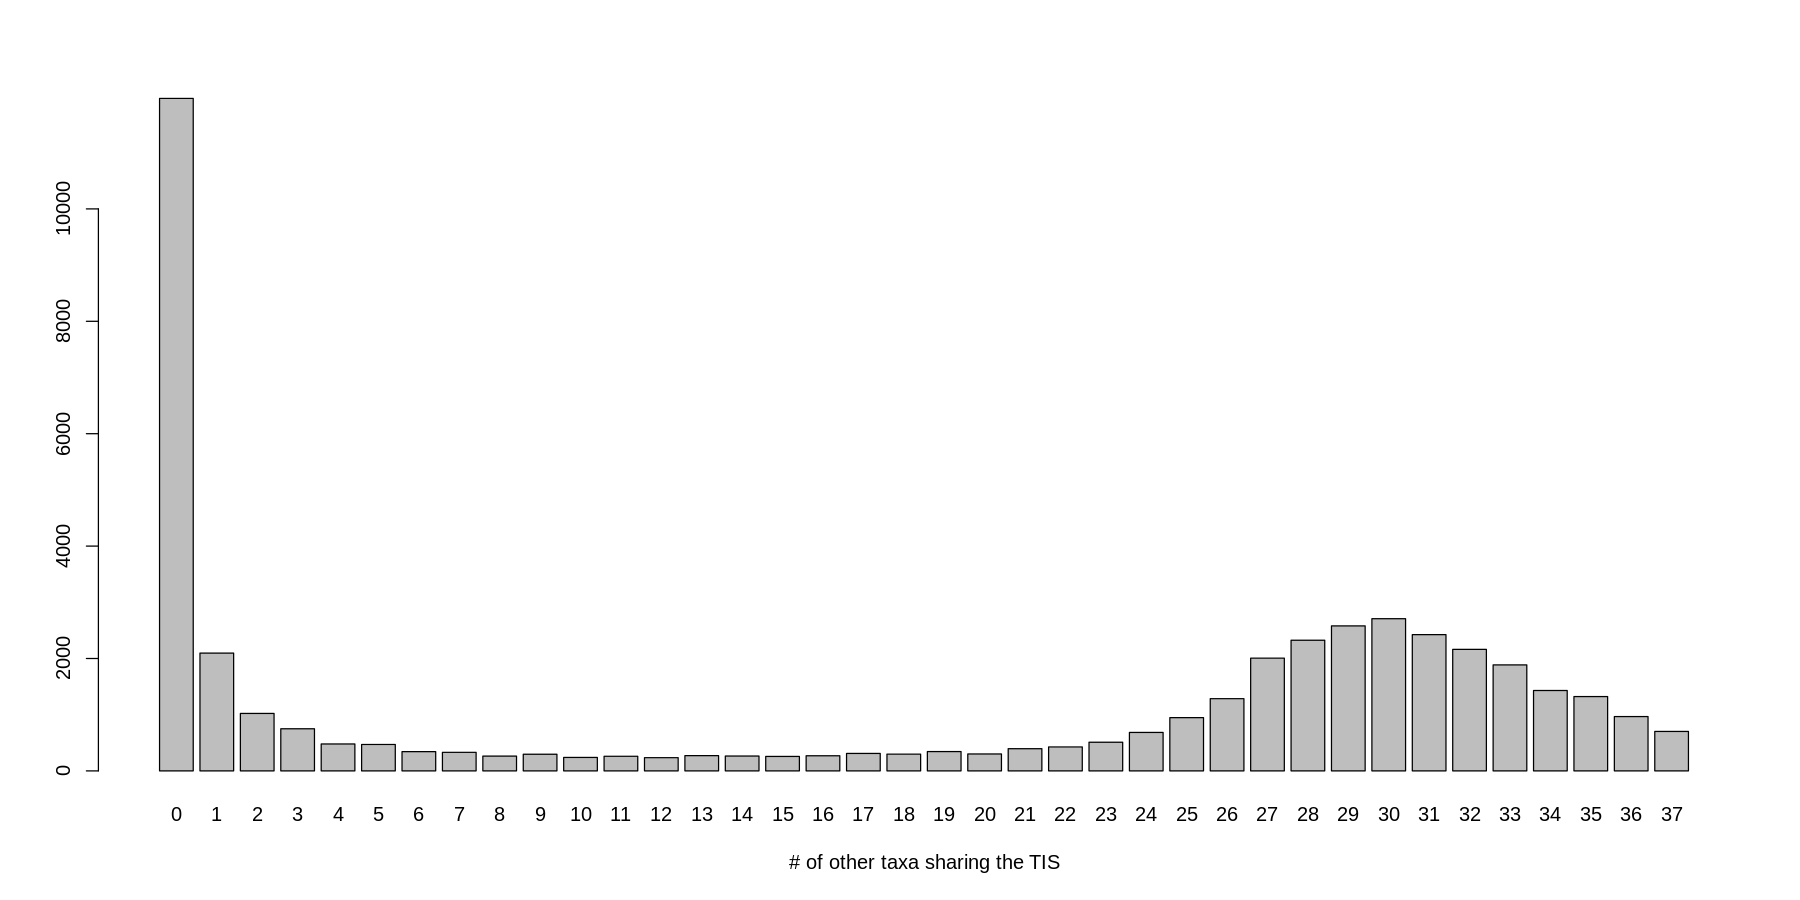

In [5]:
# examine the conservation of starting 'ATG'
options(repr.plot.width=15, repr.plot.height=7.5)
firstATGConservation = sapply(dat_list, function(x) x[1,2])
barplot(table(firstATGConservation),xlab = "# of other taxa sharing the TIS")
length(firstATGConservation)
table(firstATGConservation)

In [6]:
# examine the conservation of downstream in-frame 'ATG'
secondInFrameATGConservation = sapply(dat_list, function(x){
    tmp = x
    tmp = tmp[tmp[,3]%%3 == 0,]
    return(tmp[order(tmp[,2],decreasing = T)[1],2])
})


[1] 45843

secondInFrameATGConservation
   0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   15 
4644  846  437  321  258  172  168  156  135  144  116  105  107  140  117  140 
  16   17   18   19   20   21   22   23   24   25   26   27   28   29   30   31 
 117  133  145  134  154  152  139  191  237  393  643 1131 1789 2362 3133 3573 
  32   33   34   35   36   37 
3977 4131 3959 4016 3739 3482 

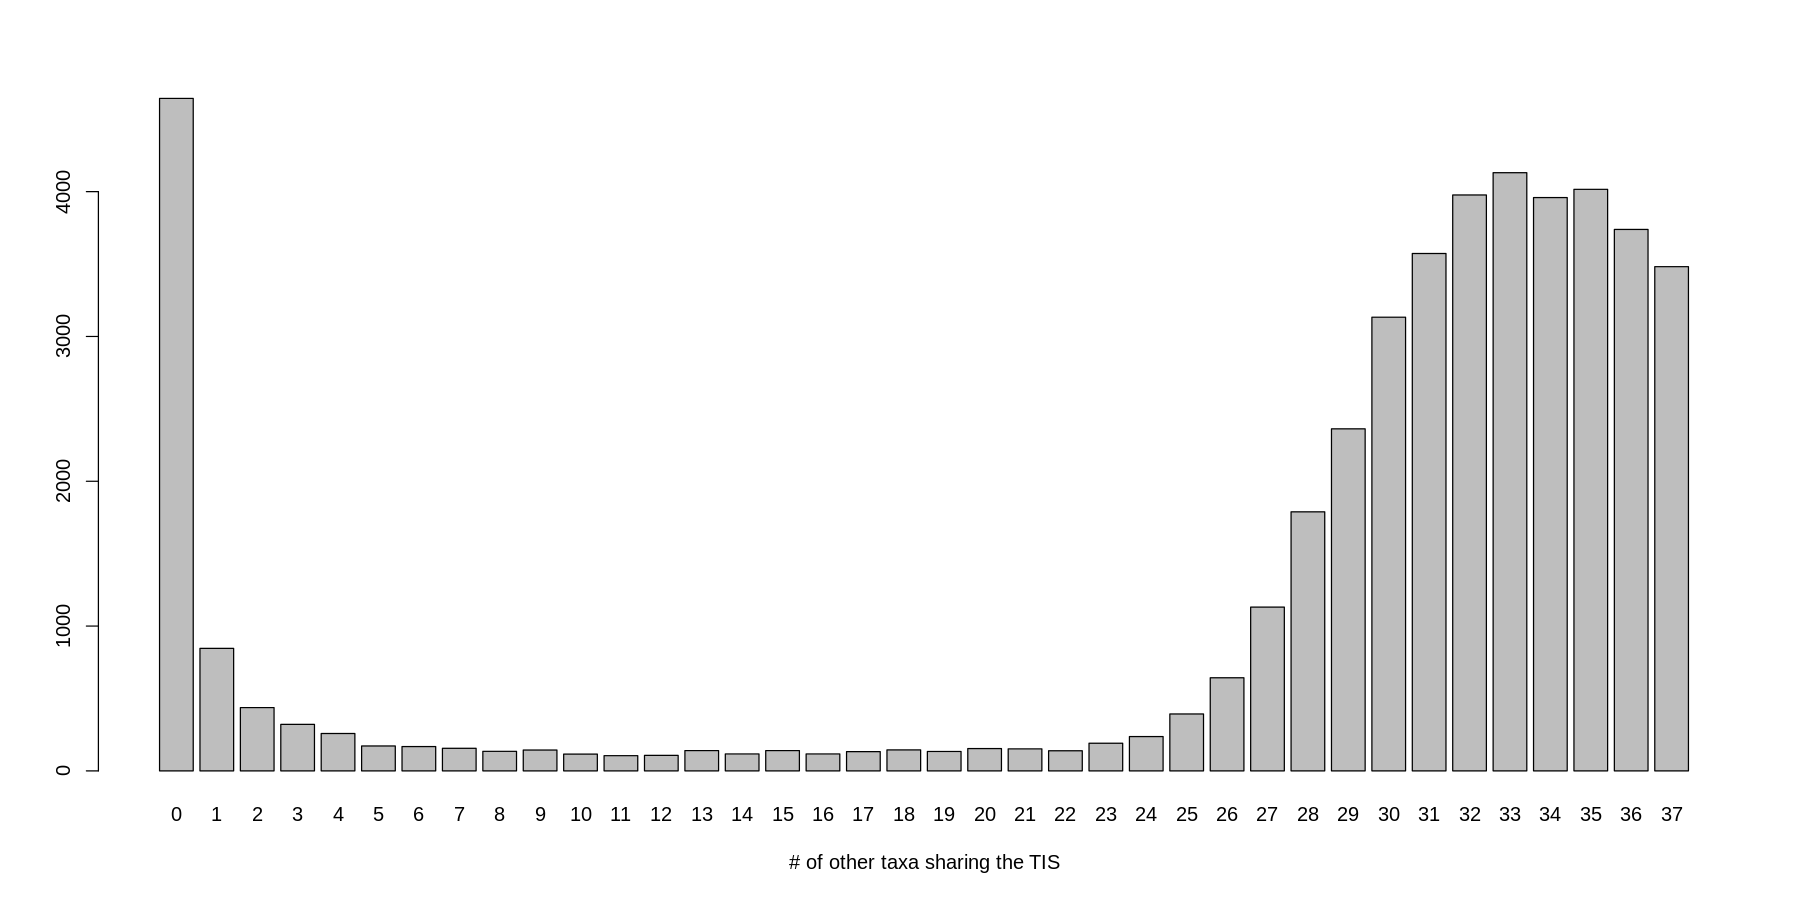

In [7]:
barplot(table(secondInFrameATGConservation),xlab = "# of other taxa sharing the TIS")
length(secondInFrameATGConservation)
table(secondInFrameATGConservation)

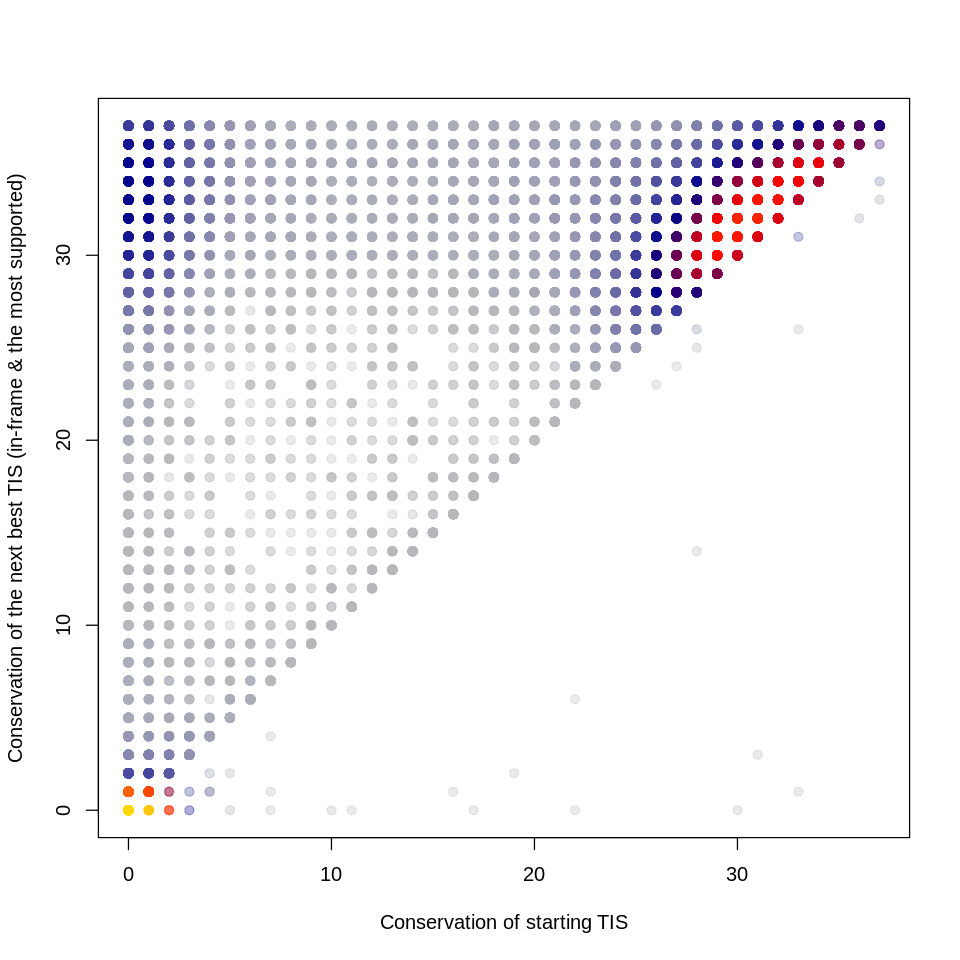

In [21]:
options(repr.plot.width=8, repr.plot.height=8)
# plot(firstATGConservation,secondInFrameATGConservation,pch = 19, col = scales::alpha("black",0.01),
#     xlab = "Conservation of starting TIS",ylab = "Conservation of the next best TIS (in-frame & the most supported)")
# cor(firstATGConservation,secondInFrameATGConservation,use = "complete",method = "spearman")
heatscatter(firstATGConservation,secondInFrameATGConservation,
            xlab = "Conservation of starting TIS",ylab = "Conservation of the next best TIS (in-frame & the most supported)",
            main = "",nrcol = 100,grid = 100,alpha = 50,cex =1)


   0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   15 
4636  840  434  175  142  101   92   79   70   69   59   41   52   60   57   53 
  16   17   18   19   20   21   22   23   24   25   26   27   28   29   30   31 
  53   49   60   53   76   63   70   79   91  111  193  297  392  516  616  729 
  32   33   34   35   36   37 
 775  850  774  774  768  687 

[1] 7974

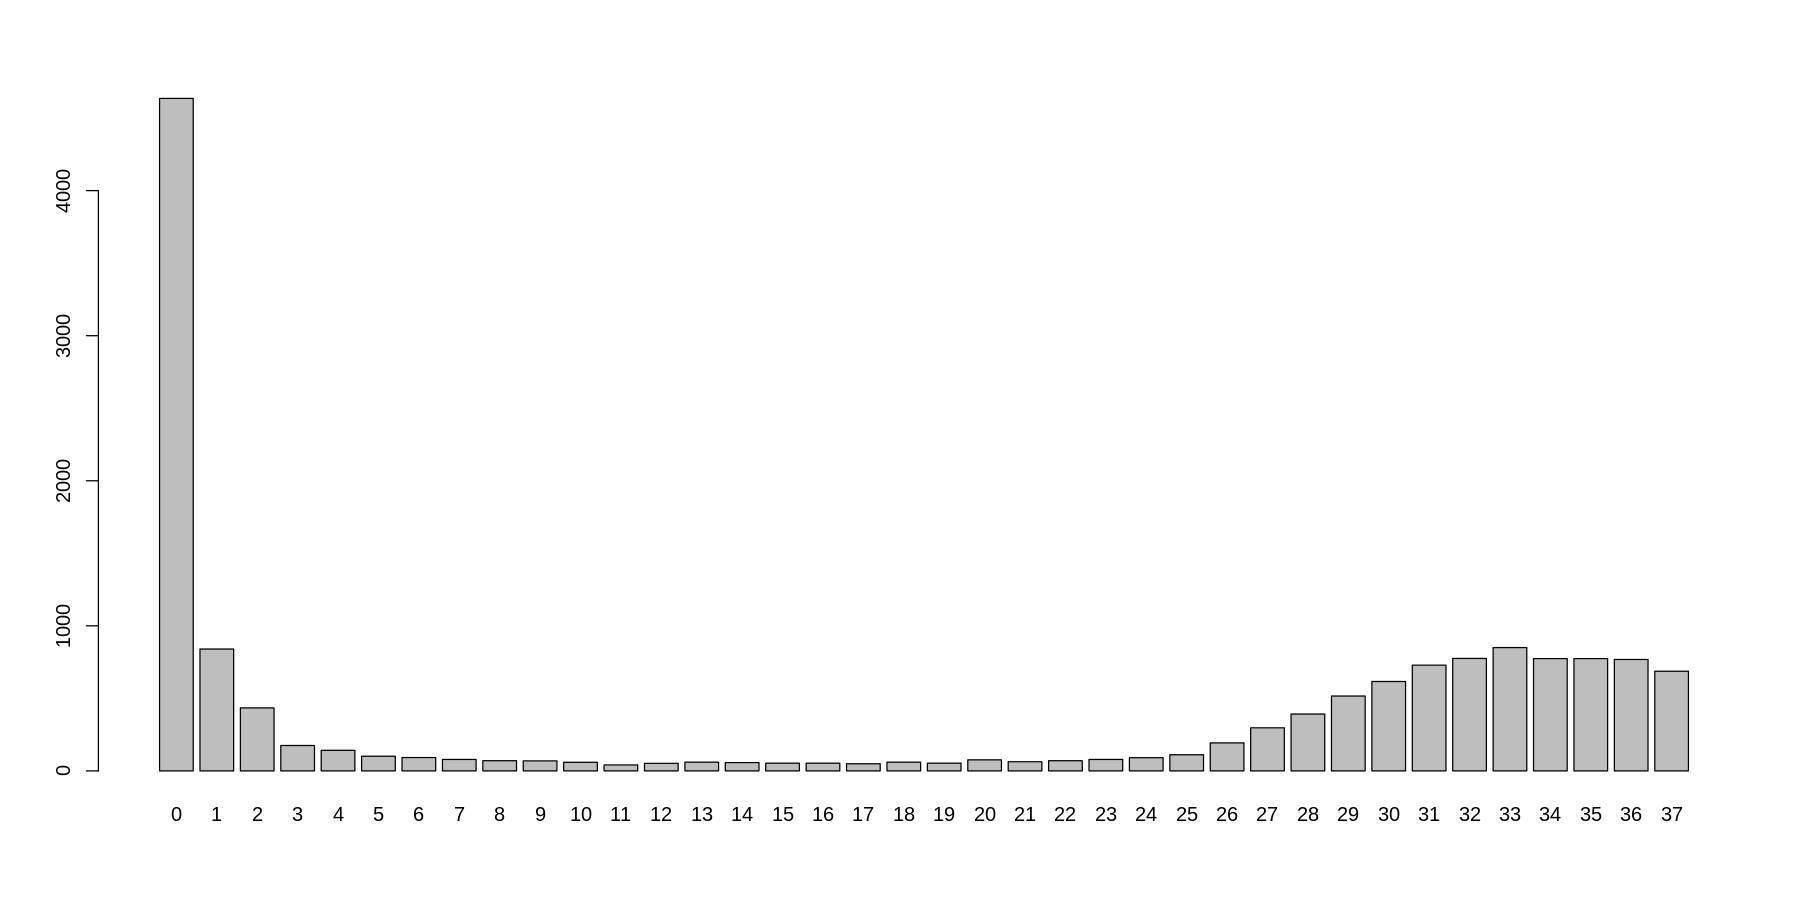

In [91]:
options(repr.plot.width=15, repr.plot.height=7.5)
table(secondInFrameATGConservation[firstATGConservation<=2])
barplot(table(secondInFrameATGConservation[firstATGConservation<=2]))
sum(table(secondInFrameATGConservation[firstATGConservation<=2])[19:38])


FALSE  TRUE 
15084 30735 


FALSE  TRUE 
 5910  9126 

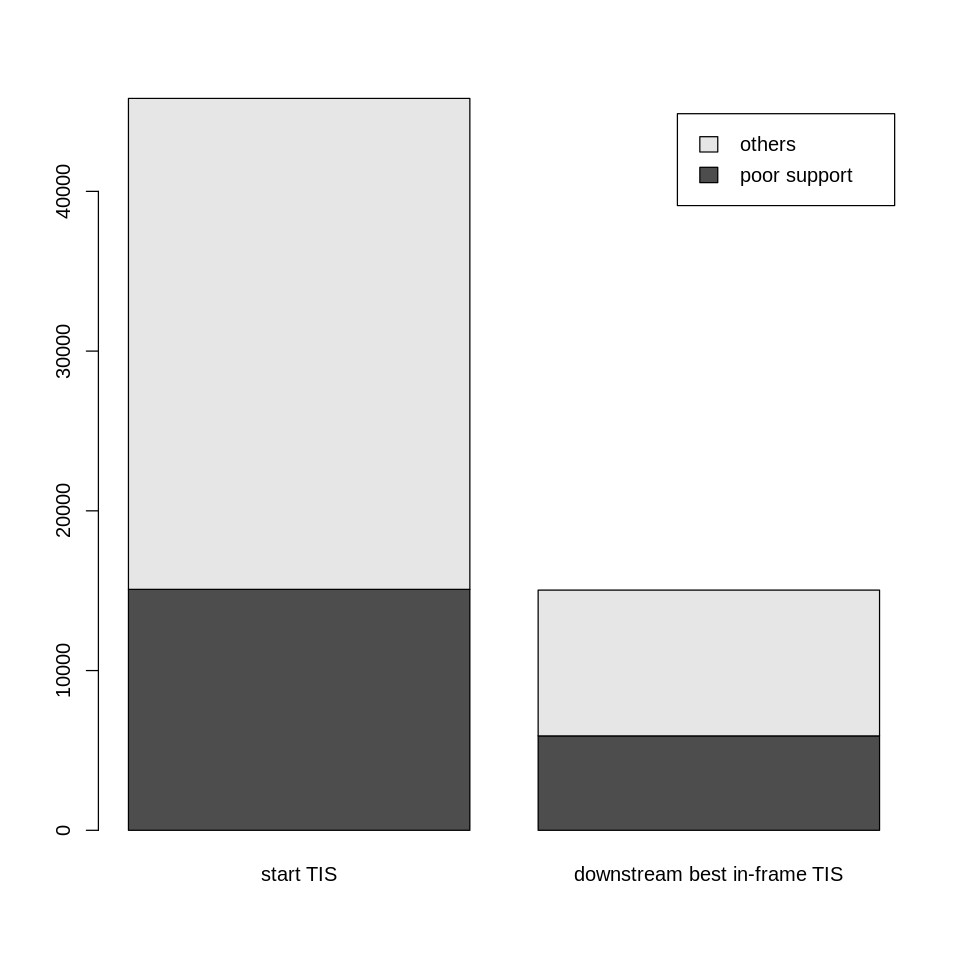

In [102]:
options(repr.plot.width=8, repr.plot.height=8)
table(firstATGConservation>=3)
table(secondInFrameATGConservation[firstATGConservation<3]>=3)
bpDat = cbind(table(firstATGConservation>=3),table(secondInFrameATGConservation[firstATGConservation<3]>=3))
barplot(bpDat,names.arg = c("start TIS","downstream best in-frame TIS"),legend.text = c("poor support","others"))

In [82]:
# examine the conservation of downstream 'ATG'
secondATGConservation = sapply(dat_list, function(x){
    tmp = x
    return(tmp[order(tmp[,2],decreasing = T)[1],2])
})


[1] 45843

secondATGConservation
   0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   15 
4088  946  428  333  264  174  163  171  146  146  124  103  105  132  110  126 
  16   17   18   19   20   21   22   23   24   25   26   27   28   29   30   31 
 111  127  141  138  158  144  143  161  227  398  630 1091 1764 2354 3075 3565 
  32   33   34   35   36   37 
3989 4197 4067 4185 3882 3713 

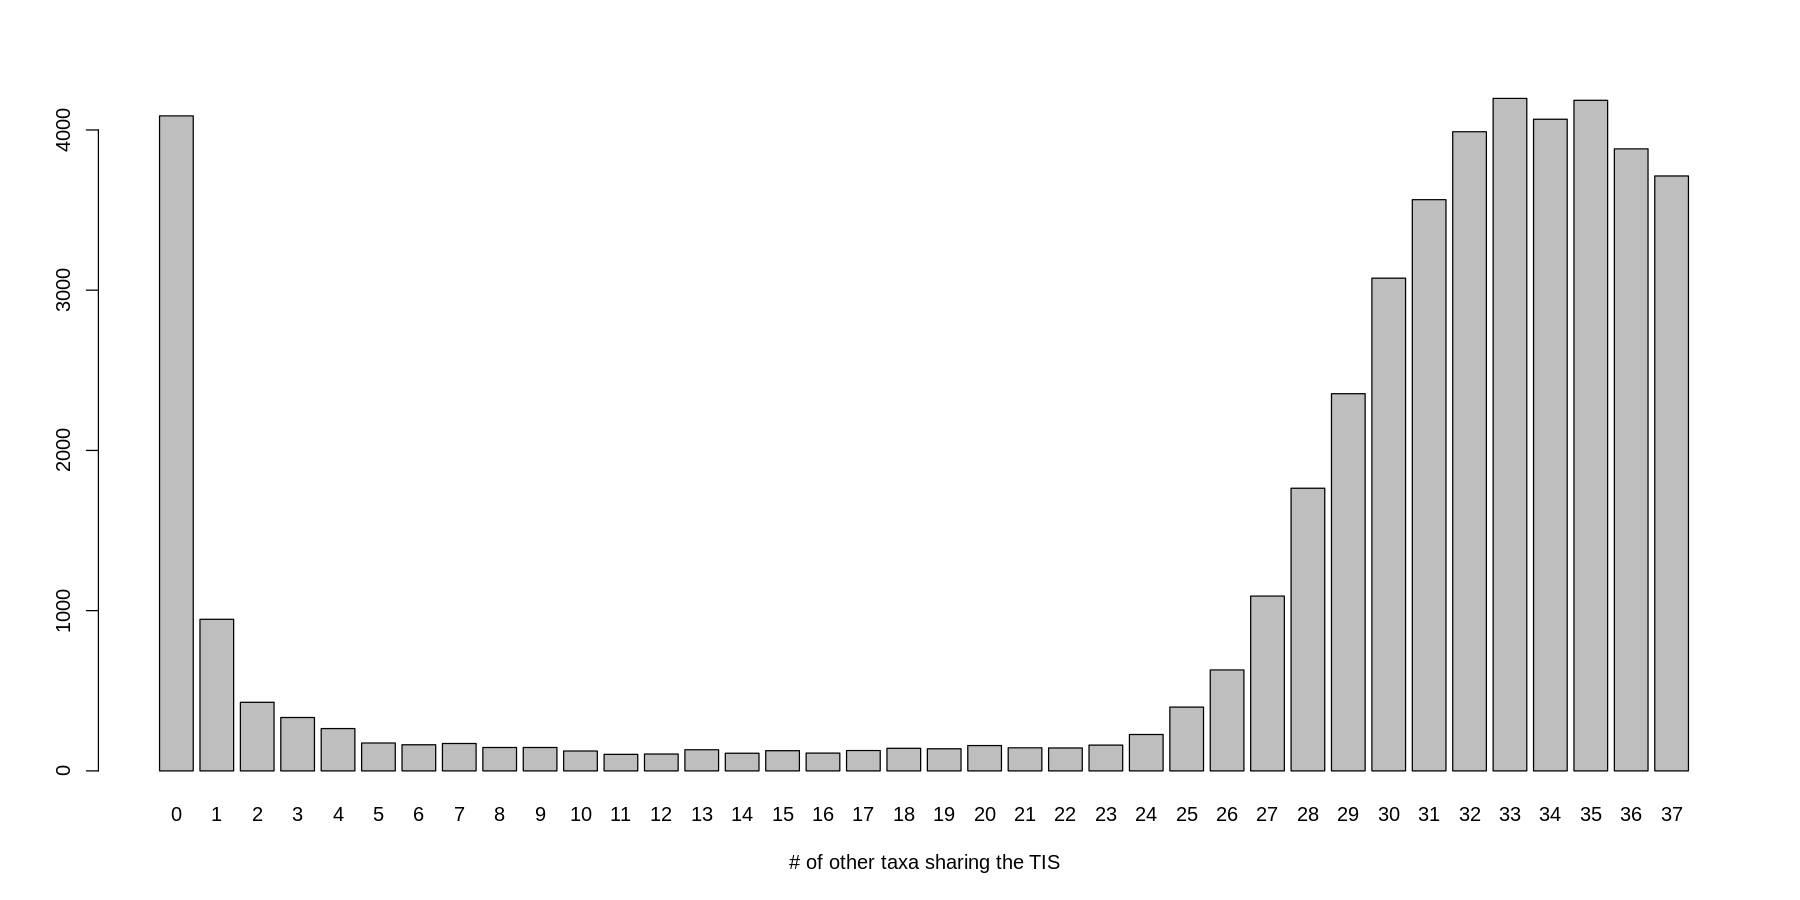

In [83]:
barplot(table(secondATGConservation),xlab = "# of other taxa sharing the TIS")
length(secondATGConservation)
table(secondATGConservation)


   0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   15 
4088  946  428  225  163  113  100  103   74   84   72   33   58   63   61   61 
  16   17   18   19   20   21   22   23   24   25   26   27   28   29   30   31 
  59   64   66   54   76   68   74   70   96  132  177  283  404  533  622  751 
  32   33   34   35   36   37 
 797  891  812  826  809  748 

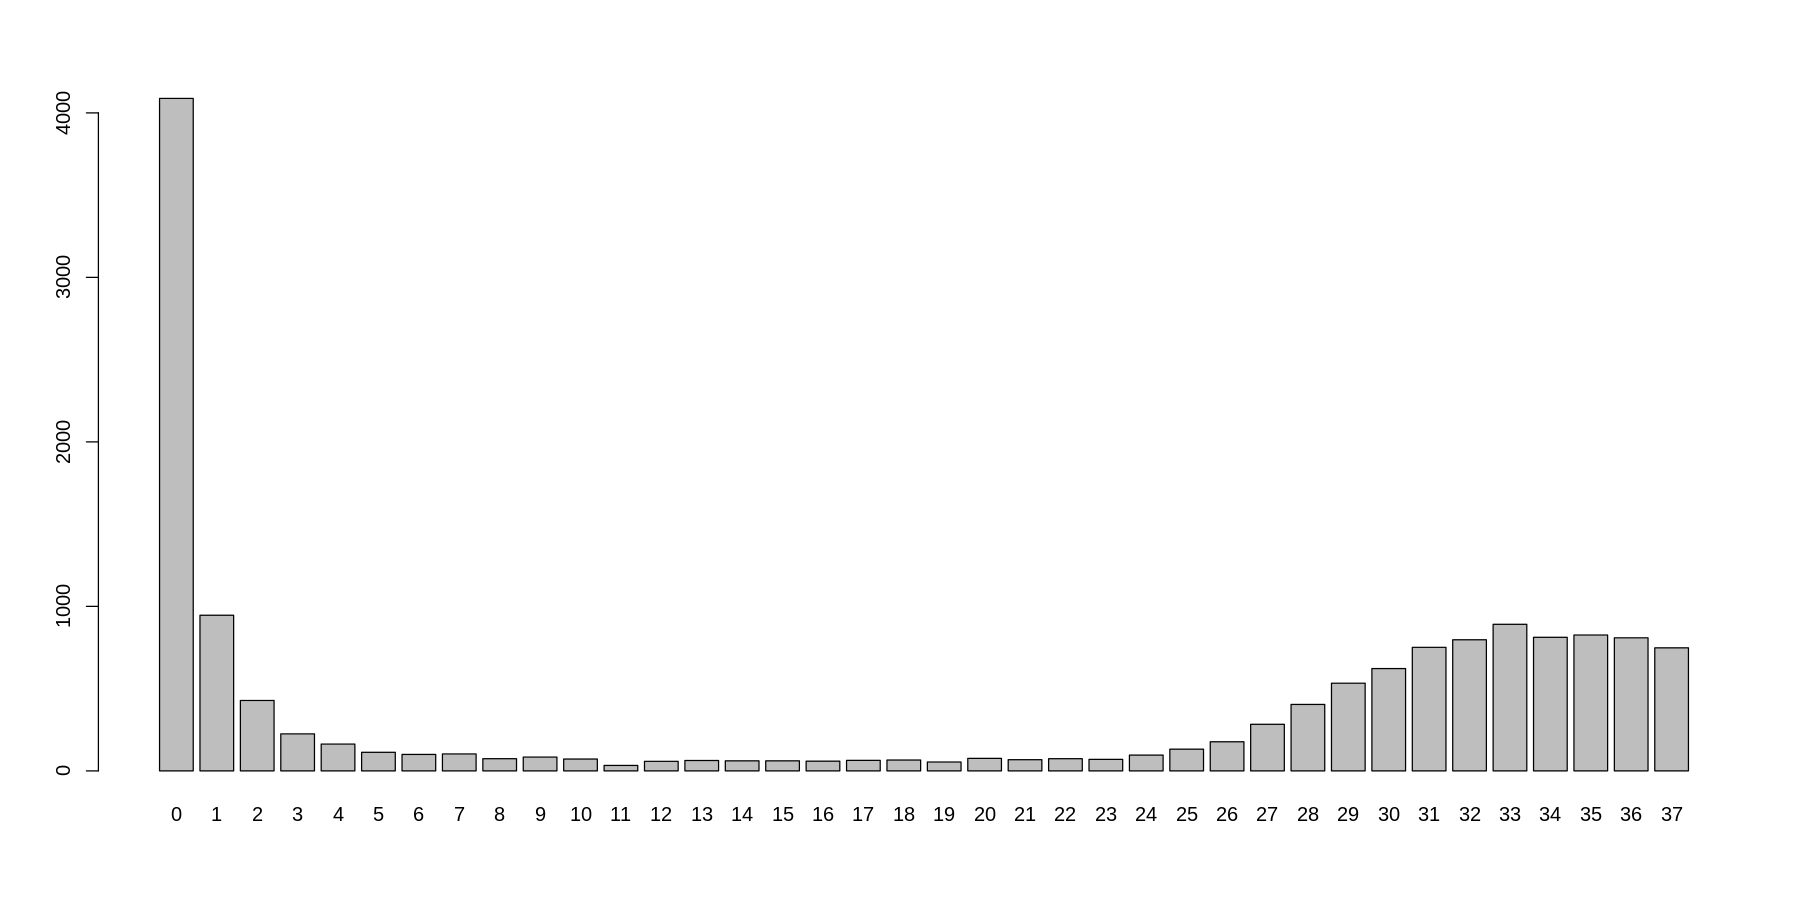

In [84]:
table(secondATGConservation[firstATGConservation<=2])
barplot(table(secondATGConservation[firstATGConservation<=2]))